# Baseline LSTM Model for Dissolved Oxygen Prediction

**Author:** IMTA Analytics Team  
**Date:** November 13, 2025  
**Objective:** Implement baseline LSTM model for DO prediction (target R² > 0.85)

## Background

Based on literature review:
- **Barzegar et al. (2020)**: LSTM baseline achieves R² = 0.90-0.93 for DO prediction
- **Xu et al. (2025)**: Advanced CNN-SA-BiSRU achieves R² = 0.9765
- **Target performance**: R² > 0.85 for initial baseline

## Data Characteristics (from exploration docs)

- **DO columns**: `EXO2DomgpL` (mg/L), `EXO2DO` (% saturation)
- **Sampling interval**: 15 minutes (96 samples/day)
- **Date range**: January-October 2025 (~9 months)
- **Data quality**: >95% valid after cleaning
- **Available features**: Temperature, Salinity, pH, Conductivity, Turbidity, Chlorophyll

## References

- `docs/analysis/20251113-data-exploration-findings.md` - Data exploration results
- `refs/publications/Barzegar et. al. - 2020 - Short-term water quality variable prediction using a hybrid CNN-LSTM deep learning model.md`
- `refs/publications/Xu et. al. - 2025 - Hybrid deep learning framework for real-time DO prediction in aquaculture.md`

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Environment setup complete.')

Environment setup complete.


## 2. Data Loading

Load processed EXO2 data (already cleaned and validated)

In [2]:
# Load cleaned EXO2 data
df_exo2 = pd.read_feather('../data/processed/exo2_data.feather')

print(f"Dataset shape: {df_exo2.shape}")
print(f"\nDate range: {df_exo2['TIMESTAMP'].min()} to {df_exo2['TIMESTAMP'].max()}")
print(f"Duration: {(df_exo2['TIMESTAMP'].max() - df_exo2['TIMESTAMP'].min()).days} days")
print(f"\nSampling interval: {df_exo2['TIMESTAMP'].diff().median()}")
print(f"Total samples: {len(df_exo2):,}")

print("\nColumn names:")
print(list(df_exo2.columns))

print("\nDataset info:")
df_exo2.info()

Dataset shape: (27109, 21)

Date range: 2024-12-20 14:32:10 to 2025-09-26 17:47:10
Duration: 280 days

Sampling interval: 0 days 00:15:00
Total samples: 27,109

Column names:
['TIMESTAMP', 'RECORD', 'EXO2Date', 'EXO2Time', 'EXO2pH', 'EXO2pHmV', 'EXO2fDOM', 'EXO2Temp', 'EXO2spCond', 'EXO2Salinity', 'EXO2Turb', 'EXO2Chlor', 'EXO2ChlorugpL', 'EXO2BGAPE', 'EXO2BGAPEugpL', 'EXO2DO', 'EXO2DomgpL', 'EXO2Depth', 'EXO2IntPwr', 'EXO2ExtPwr', 'time_diff']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27109 entries, 0 to 27108
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   TIMESTAMP      27109 non-null  datetime64[ns] 
 1   RECORD         27109 non-null  int64          
 2   EXO2Date       26962 non-null  float64        
 3   EXO2Time       26962 non-null  float64        
 4   EXO2pH         25864 non-null  float64        
 5   EXO2pHmV       25864 non-null  float64        
 6   EXO2fD

## 3. Data Validation and Exploration

In [3]:
# Check for DO column and missing values
print("Missing values per column:")
print(df_exo2.isnull().sum())

print("\nDO statistics (mg/L):")
print(df_exo2['EXO2DomgpL'].describe())

print("\nDO statistics (% saturation):")
print(df_exo2['EXO2DO'].describe())

Missing values per column:
TIMESTAMP           0
RECORD              0
EXO2Date          147
EXO2Time          147
EXO2pH           1245
EXO2pHmV         1245
EXO2fDOM          147
EXO2Temp         1248
EXO2spCond       1245
EXO2Salinity     1248
EXO2Turb         1253
EXO2Chlor        1248
EXO2ChlorugpL    1245
EXO2BGAPE        1245
EXO2BGAPEugpL     147
EXO2DO           1248
EXO2DomgpL       1245
EXO2Depth        1248
EXO2IntPwr        147
EXO2ExtPwr        147
time_diff           1
dtype: int64

DO statistics (mg/L):
count    25864.000000
mean         9.919886
std          1.309156
min          6.600000
25%          8.980000
50%          9.900000
75%         11.060000
max         13.650000
Name: EXO2DomgpL, dtype: float64

DO statistics (% saturation):
count    25861.000000
mean       103.801976
std          6.621078
min         78.930000
25%         99.980000
50%        103.780000
75%        107.800000
max        127.840000
Name: EXO2DO, dtype: float64


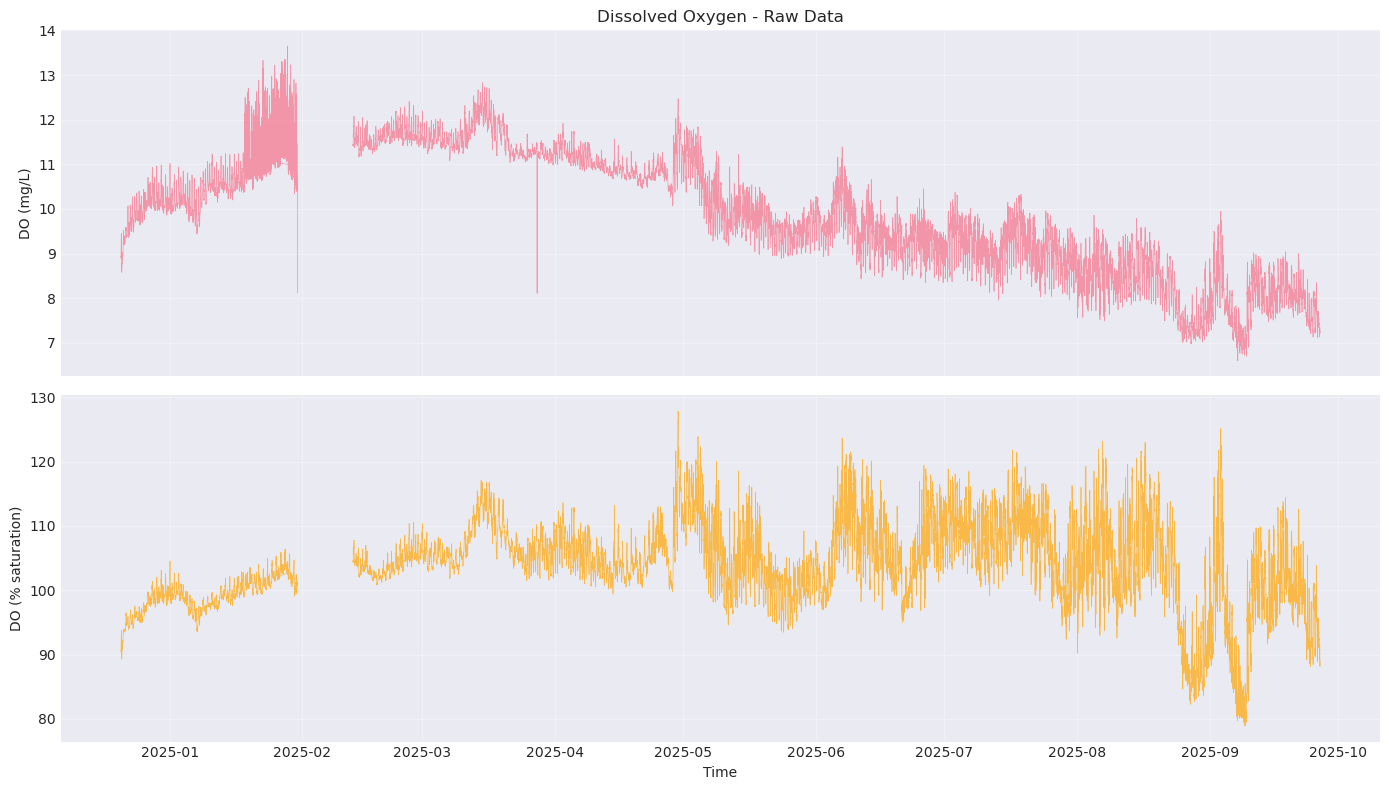


DO range (mg/L): 6.60 - 13.65
DO range (% sat): 78.93 - 127.84


In [4]:
# Visualize DO timeseries
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df_exo2['TIMESTAMP'], df_exo2['EXO2DomgpL'], linewidth=0.5, alpha=0.7)
ax1.set_ylabel('DO (mg/L)')
ax1.set_title('Dissolved Oxygen - Raw Data')
ax1.grid(True, alpha=0.3)

ax2.plot(df_exo2['TIMESTAMP'], df_exo2['EXO2DO'], linewidth=0.5, alpha=0.7, color='orange')
ax2.set_ylabel('DO (% saturation)')
ax2.set_xlabel('Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDO range (mg/L): {df_exo2['EXO2DomgpL'].min():.2f} - {df_exo2['EXO2DomgpL'].max():.2f}")
print(f"DO range (% sat): {df_exo2['EXO2DO'].min():.2f} - {df_exo2['EXO2DO'].max():.2f}")

## 4. Feature Selection

Select features based on Barzegar et al. (2020) and available data

In [5]:
# Feature selection - using % saturation as it's more stable
feature_cols = [
    'EXO2DO',      # Target variable (% saturation)
    'EXO2Temp',       # Temperature (strong inverse correlation)
    'EXO2spCond',     # Specific Conductivity
    'EXO2Salinity',        # Salinity
    'EXO2pH',         # pH (photosynthesis linkage)
    'EXO2Turb',       # Turbidity
    'EXO2Chlor'         # Chlorophyll (photosynthesis indicator)
]

# Create working dataframe
df_work = df_exo2[['TIMESTAMP'] + feature_cols].copy()

# Drop rows with any missing values
df_work = df_work.dropna()

# Sort by timestamp (should already be sorted, but ensure)
df_work = df_work.sort_values('TIMESTAMP').reset_index(drop=True)

print(f"Working dataset shape: {df_work.shape}")
print(f"Features selected: {len(feature_cols)}")
print(f"Samples after dropping NaN: {len(df_work):,}")

Working dataset shape: (25856, 8)
Features selected: 7
Samples after dropping NaN: 25,856


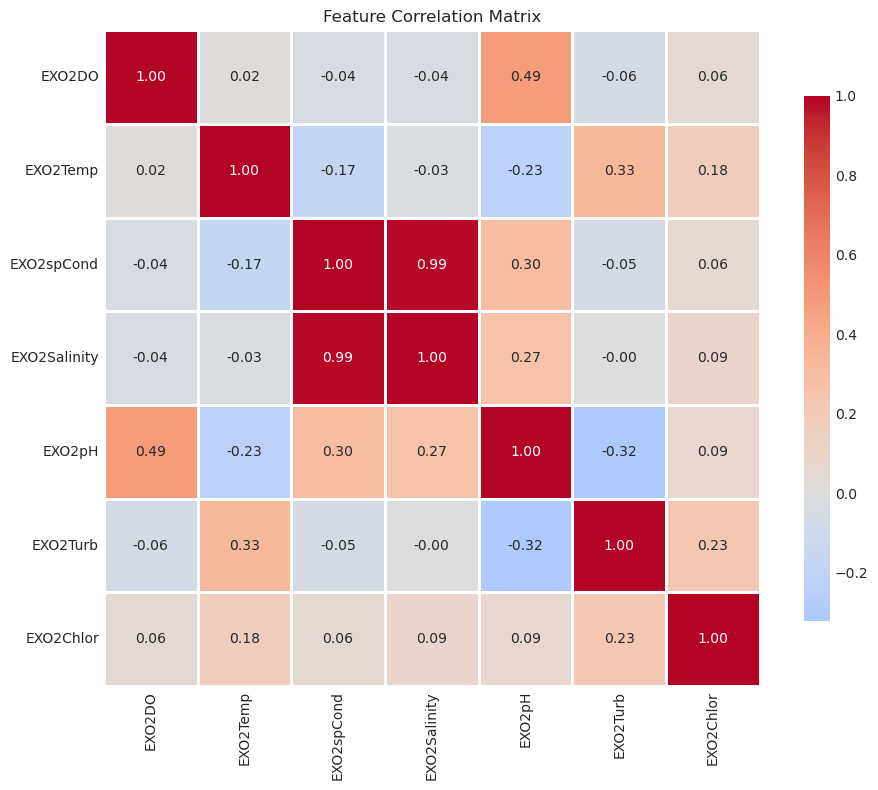


Correlations with DO (% saturation):
EXO2DO          1.000000
EXO2pH          0.485528
EXO2Chlor       0.057327
EXO2Temp        0.015422
EXO2spCond     -0.041952
EXO2Salinity   -0.044881
EXO2Turb       -0.063760
Name: EXO2DO, dtype: float64


In [6]:
# Correlation analysis
corr_matrix = df_work[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelations with DO (% saturation):")
print(corr_matrix['EXO2DO'].sort_values(ascending=False))

## 5. Feature Engineering

Create lag features and temporal encodings following Xu et al. (2025)

In [7]:
from sklearn.preprocessing import MinMaxScaler

# 1. Normalize features to [0, 1]
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_work[feature_cols]),
    columns=feature_cols,
    index=df_work.index
)

print("Features normalized to [0, 1] range")
print(df_scaled.describe())

Features normalized to [0, 1] range
             EXO2DO      EXO2Temp    EXO2spCond  EXO2Salinity        EXO2pH  \
count  25856.000000  25856.000000  25856.000000  25856.000000  25856.000000   
mean       0.508519      0.463345      0.879617      0.900331      0.493708   
std        0.135380      0.275888      0.093395      0.096427      0.138905   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.430382      0.215202      0.854667      0.874631      0.411765   
50%        0.508076      0.475674      0.898682      0.930310      0.509804   
75%        0.590268      0.726023      0.927595      0.954277      0.588235   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

           EXO2Turb     EXO2Chlor  
count  25856.000000  25856.000000  
mean       0.025045      0.057092  
std        0.040193      0.047122  
min        0.000000      0.000000  
25%        0.007116      0.030012  
50%        0.011842      0.045618  


In [8]:
# 2. Create temporal lag features for DO
# 15-min intervals: 12 lags = 3 hours of history
n_lags = 12

df_features = df_scaled.copy()

for lag in range(1, n_lags + 1):
    df_features[f'EXO2DO_lag{lag}'] = df_features['EXO2DO'].shift(lag)

print(f"Created {n_lags} lag features (3 hours of history)")
print(f"New feature count: {len(df_features.columns)}")

Created 12 lag features (3 hours of history)
New feature count: 19


In [9]:
# 3. Add time-based features (circular encoding)
timestamps = df_work['TIMESTAMP'].values
timestamps_dt = pd.to_datetime(timestamps)

df_features['hour_sin'] = np.sin(2 * np.pi * timestamps_dt.hour / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * timestamps_dt.hour / 24)
df_features['day_sin'] = np.sin(2 * np.pi * timestamps_dt.dayofyear / 365)
df_features['day_cos'] = np.cos(2 * np.pi * timestamps_dt.dayofyear / 365)

print("Added circular time features: hour_sin, hour_cos, day_sin, day_cos")

Added circular time features: hour_sin, hour_cos, day_sin, day_cos


In [10]:
# 4. Drop rows with NaN from lag creation
df_features = df_features.dropna()

print(f"\nFinal dataset shape after lag creation: {df_features.shape}")
print(f"Rows dropped due to lag NaN: {len(df_scaled) - len(df_features)}")
print(f"\nFinal feature columns ({len(df_features.columns)} total):")
print(list(df_features.columns))


Final dataset shape after lag creation: (25844, 23)
Rows dropped due to lag NaN: 12

Final feature columns (23 total):
['EXO2DO', 'EXO2Temp', 'EXO2spCond', 'EXO2Salinity', 'EXO2pH', 'EXO2Turb', 'EXO2Chlor', 'EXO2DO_lag1', 'EXO2DO_lag2', 'EXO2DO_lag3', 'EXO2DO_lag4', 'EXO2DO_lag5', 'EXO2DO_lag6', 'EXO2DO_lag7', 'EXO2DO_lag8', 'EXO2DO_lag9', 'EXO2DO_lag10', 'EXO2DO_lag11', 'EXO2DO_lag12', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


## 6. Train/Test Split

Chronological split (no shuffling) - 80% train, 20% test

In [11]:
# Chronological split
split_idx = int(len(df_features) * 0.8)

train_df = df_features.iloc[:split_idx]
test_df = df_features.iloc[split_idx:]

# Separate features and target
feature_names = [col for col in df_features.columns if col != 'EXO2DO']
X_train = train_df[feature_names].values
y_train = train_df['EXO2DO'].values
X_test = test_df[feature_names].values
y_test = test_df['EXO2DO'].values

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Train/test split: {len(X_train)/len(df_features)*100:.1f}% / {len(X_test)/len(df_features)*100:.1f}%")
print(f"\nNumber of features: {X_train.shape[1]}")

Training samples: 20,675
Test samples: 5,169
Train/test split: 80.0% / 20.0%

Number of features: 22


In [12]:
# Reshape for LSTM [samples, timesteps, features]
# Using timesteps=1 for baseline (each sample is independent)
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"LSTM input shape (train): {X_train_lstm.shape}")
print(f"LSTM input shape (test): {X_test_lstm.shape}")
print(f"Format: (samples, timesteps, features)")

LSTM input shape (train): (20675, 1, 22)
LSTM input shape (test): (5169, 1, 22)
Format: (samples, timesteps, features)


## 7. LSTM Model Architecture

Baseline architecture from Barzegar et al. (2020)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Model architecture
model = Sequential([
    LSTM(64, activation='elu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.001),
    Dense(1, activation='linear')  # Regression output
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

print("Model architecture:")
model.summary()

2025-11-13 21:43:57.181828: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 21:43:57.276180: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Model Training

Train with early stopping to prevent overfitting

In [14]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train model
print("Training LSTM model...")
history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,  # Use 20% of training for validation
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete.")

Training LSTM model...
Epoch 1/100



  1/517 ━━━━━━━━━━━━━━━━━━━━ 8:40 1s/step - loss: 0.2998 - mae: 0.5398


 33/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0622 - mae: 0.1881 


 68/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0395 - mae: 0.1376


106/517 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0293 - mae: 0.1119

...


491/517 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.0804e-04 - mae: 0.0140


517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.0860e-04 - mae: 0.0139 - val_loss: 0.0043 - val_mae: 0.0572


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.



Training complete.


## 9. Model Evaluation

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions
y_pred_train = model.predict(X_train_lstm, verbose=0).flatten()
y_pred_test = model.predict(X_test_lstm, verbose=0).flatten()

print("Predictions generated")
print(f"Train predictions shape: {y_pred_train.shape}")
print(f"Test predictions shape: {y_pred_test.shape}")

Predictions generated
Train predictions shape: (20675,)
Test predictions shape: (5169,)


In [16]:
# Inverse transform to original scale
# Create dummy arrays with zeros for non-DO features
n_features = len(feature_cols)

# Training set
y_train_matrix = np.column_stack([y_train] + [np.zeros(len(y_train))] * (n_features - 1))
y_train_orig = scaler.inverse_transform(y_train_matrix)[:, 0]

y_pred_train_matrix = np.column_stack([y_pred_train] + [np.zeros(len(y_pred_train))] * (n_features - 1))
y_pred_train_orig = scaler.inverse_transform(y_pred_train_matrix)[:, 0]

# Test set
y_test_matrix = np.column_stack([y_test] + [np.zeros(len(y_test))] * (n_features - 1))
y_test_orig = scaler.inverse_transform(y_test_matrix)[:, 0]

y_pred_test_matrix = np.column_stack([y_pred_test] + [np.zeros(len(y_pred_test))] * (n_features - 1))
y_pred_test_orig = scaler.inverse_transform(y_pred_test_matrix)[:, 0]

print("Predictions inverse-transformed to original scale (% saturation)")

Predictions inverse-transformed to original scale (% saturation)


In [17]:
# Calculate metrics
r2_train = r2_score(y_train_orig, y_pred_train_orig)
r2_test = r2_score(y_test_orig, y_pred_test_orig)
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Training R²:   {r2_train:.4f}")
print(f"Test R²:       {r2_test:.4f}")
print(f"Test MAE:      {mae_test:.4f} % saturation")
print(f"Test RMSE:     {rmse_test:.4f} % saturation")
print("="*60)
print("\nLiterature Benchmarks (Barzegar et al. 2020):")
print("  Target R² > 0.85")
print("  LSTM baseline: R² = 0.90-0.93")
print("="*60)

if r2_test >= 0.85:
    print("\nPERFORMANCE: Target achieved (R² >= 0.85)")
    if r2_test >= 0.90:
        print("EXCELLENT: Matches literature baseline performance")
else:
    print("\nWARNING: Below target performance (R² < 0.85)")
    print("Consider: More lag features, hyperparameter tuning, or advanced architectures")

MODEL PERFORMANCE METRICS
Training R²:   0.9389
Test R²:       0.8300
Test MAE:      3.3089 % saturation
Test RMSE:     3.7758 % saturation

Literature Benchmarks (Barzegar et al. 2020):
  Target R² > 0.85
  LSTM baseline: R² = 0.90-0.93

Consider: More lag features, hyperparameter tuning, or advanced architectures


## 10. Visualization

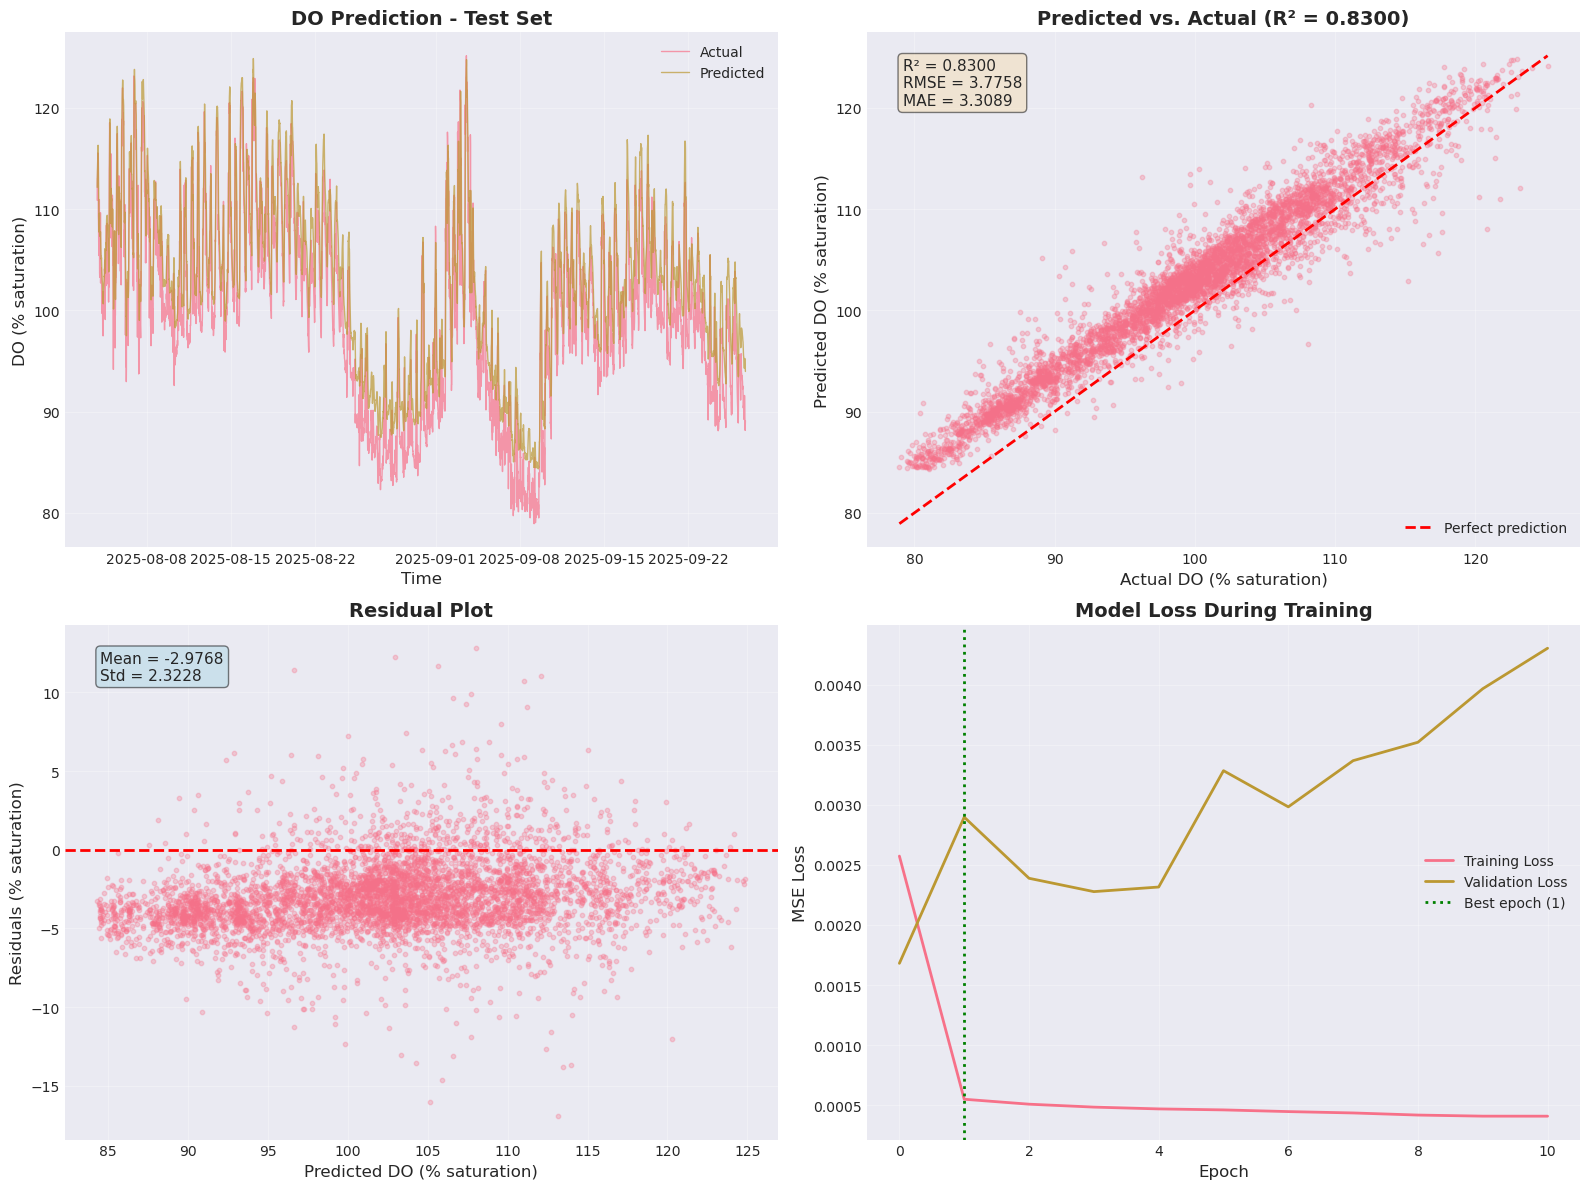

Visualization saved to: docs/analysis/lstm_baseline_results.png


In [18]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get test timestamps
test_timestamps = df_work.iloc[split_idx + n_lags:]['TIMESTAMP'].values

# 1. Time series comparison
axes[0, 0].plot(test_timestamps, y_test_orig, label='Actual', alpha=0.7, linewidth=1)
axes[0, 0].plot(test_timestamps, y_pred_test_orig, label='Predicted', alpha=0.7, linewidth=1)
axes[0, 0].set_title('DO Prediction - Test Set', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Time', fontsize=12)
axes[0, 0].set_ylabel('DO (% saturation)', fontsize=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter plot
axes[0, 1].scatter(y_test_orig, y_pred_test_orig, alpha=0.3, s=10)
axes[0, 1].plot([y_test_orig.min(), y_test_orig.max()], 
                [y_test_orig.min(), y_test_orig.max()], 
                'r--', linewidth=2, label='Perfect prediction')
axes[0, 1].set_title(f'Predicted vs. Actual (R² = {r2_test:.4f})', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Actual DO (% saturation)', fontsize=12)
axes[0, 1].set_ylabel('Predicted DO (% saturation)', fontsize=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Add R² and RMSE text
textstr = f'R² = {r2_test:.4f}\nRMSE = {rmse_test:.4f}\nMAE = {mae_test:.4f}'
axes[0, 1].text(0.05, 0.95, textstr, transform=axes[0, 1].transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Residuals
residuals = y_test_orig - y_pred_test_orig
axes[1, 0].scatter(y_pred_test_orig, residuals, alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Predicted DO (% saturation)', fontsize=12)
axes[1, 0].set_ylabel('Residuals (% saturation)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Add residual statistics
res_mean = np.mean(residuals)
res_std = np.std(residuals)
res_text = f'Mean = {res_mean:.4f}\nStd = {res_std:.4f}'
axes[1, 0].text(0.05, 0.95, res_text, transform=axes[1, 0].transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 4. Training history
axes[1, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1, 1].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('MSE Loss', fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Add early stopping epoch
best_epoch = len(history.history['loss']) - early_stop.patience
axes[1, 1].axvline(x=best_epoch, color='green', linestyle=':', linewidth=2, label=f'Best epoch ({best_epoch})')
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/analysis/lstm_baseline_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: docs/analysis/lstm_baseline_results.png")

## 11. Additional Analysis - Error Distribution

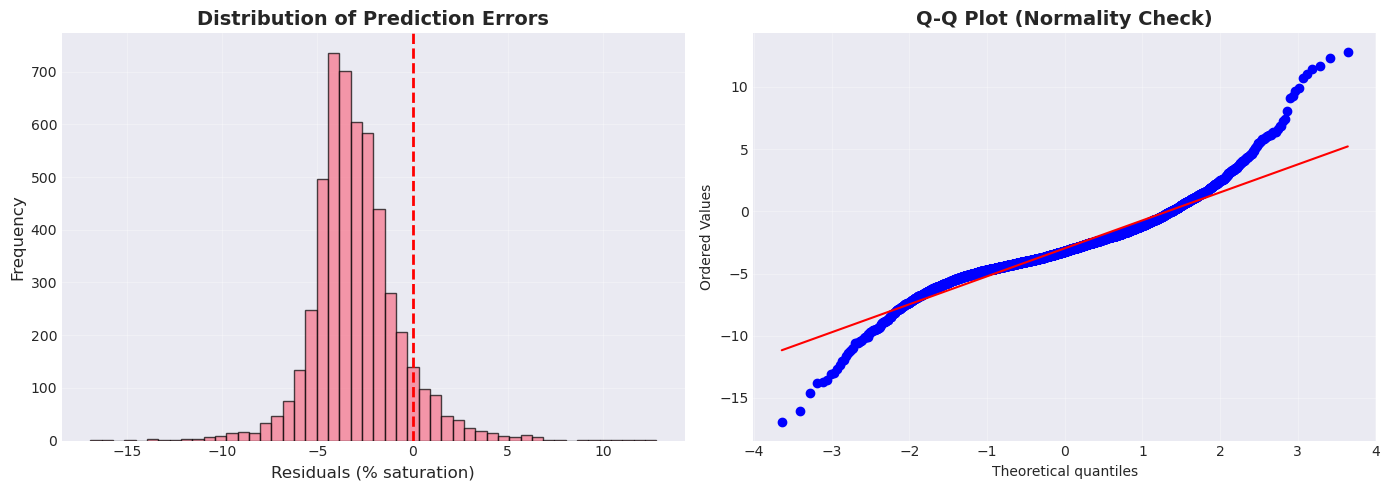


Shapiro-Wilk test for normality:
  Statistic: 0.9345
  P-value: 2.3108e-42
  Result: Residuals deviate from normal distribution (p < 0.05)


In [19]:
# Error distribution analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
ax1.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Residuals (% saturation)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Q-Q plot for normality check
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Limit to 5000 samples for test
print(f"\nShapiro-Wilk test for normality:")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("  Result: Residuals are normally distributed (p > 0.05)")
else:
    print("  Result: Residuals deviate from normal distribution (p < 0.05)")

## 12. Save Model and Results

In [20]:
import json
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save model
model_path = models_dir / 'lstm_baseline_do.h5'
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save scaler for future predictions
scaler_path = models_dir / 'scaler_do.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Save metadata
metadata = {
    'model_type': 'LSTM Baseline',
    'target': 'EXO2DO (% saturation)',
    'created_date': '2025-11-13',
    'features': {
        'base_features': feature_cols,
        'lag_features': n_lags,
        'temporal_features': ['hour_sin', 'hour_cos', 'day_sin', 'day_cos'],
        'total_features': len(feature_names)
    },
    'data': {
        'train_samples': int(len(X_train)),
        'test_samples': int(len(X_test)),
        'train_test_split': '80/20',
        'date_range': f"{df_work['TIMESTAMP'].min()} to {df_work['TIMESTAMP'].max()}",
        'sampling_interval': '15 minutes'
    },
    'performance': {
        'r2_train': float(r2_train),
        'r2_test': float(r2_test),
        'mae_test': float(mae_test),
        'rmse_test': float(rmse_test),
        'units': '% saturation'
    },
    'architecture': {
        'lstm_units': 64,
        'dropout_rate': 0.001,
        'activation': 'elu',
        'optimizer': 'Adam',
        'learning_rate': 0.01,
        'loss': 'mse',
        'epochs_trained': len(history.history['loss']),
        'early_stopping_patience': 10
    },
    'references': [
        'Barzegar et al. (2020) - CNN-LSTM hybrid model',
        'Xu et al. (2025) - CNN-SA-BiSRU architecture'
    ]
}

metadata_path = models_dir / 'lstm_baseline_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"Metadata saved to: {metadata_path}")

print("\nAll artifacts saved successfully.")

Model saved to: ../models/lstm_baseline_do.h5
Scaler saved to: ../models/scaler_do.pkl
Metadata saved to: ../models/lstm_baseline_metadata.json

All artifacts saved successfully.


## 13. Summary and Next Steps

In [21]:
print("="*80)
print("BASELINE LSTM MODEL SUMMARY")
print("="*80)
print(f"\nTarget Variable: Dissolved Oxygen (% saturation)")
print(f"Training Samples: {len(X_train):,}")
print(f"Test Samples: {len(X_test):,}")
print(f"Total Features: {len(feature_names)}")
print(f"  - Base features: {len(feature_cols)}")
print(f"  - Lag features: {n_lags}")
print(f"  - Temporal features: 4")

print(f"\nModel Architecture:")
print(f"  - LSTM units: 64")
print(f"  - Dropout: 0.001")
print(f"  - Activation: ELU")
print(f"  - Optimizer: Adam (lr=0.01)")
print(f"  - Epochs trained: {len(history.history['loss'])}")

print(f"\nPerformance Metrics:")
print(f"  - Training R²: {r2_train:.4f}")
print(f"  - Test R²: {r2_test:.4f}")
print(f"  - Test MAE: {mae_test:.4f} % saturation")
print(f"  - Test RMSE: {rmse_test:.4f} % saturation")

print(f"\nLiterature Comparison:")
print(f"  - Target: R² > 0.85")
print(f"  - Barzegar et al. (2020): R² = 0.90-0.93")
print(f"  - This model: R² = {r2_test:.4f}")

if r2_test >= 0.90:
    status = "EXCELLENT - Matches literature baseline"
elif r2_test >= 0.85:
    status = "GOOD - Meets target performance"
else:
    status = "NEEDS IMPROVEMENT - Below target"
    
print(f"  - Status: {status}")

print(f"\nDeliverables:")
print(f"  - Notebook: notebooks/02_baseline_do_prediction_lstm.ipynb")
print(f"  - Model: models/lstm_baseline_do.h5")
print(f"  - Scaler: models/scaler_do.pkl")
print(f"  - Metadata: models/lstm_baseline_metadata.json")
print(f"  - Visualization: docs/analysis/lstm_baseline_results.png")

print(f"\nNext Steps:")
if r2_test >= 0.90:
    print("  1. Document results in analysis report")
    print("  2. Explore advanced architectures (CNN-LSTM, CNN-SA-BiSRU)")
    print("  3. Implement real-time prediction pipeline")
    print("  4. Extend to multi-step forecasting (1-6 hours ahead)")
else:
    print("  1. Increase lag window (try 24 lags = 6 hours)")
    print("  2. Hyperparameter tuning (learning rate, LSTM units)")
    print("  3. Add more features (wind, solar radiation if available)")
    print("  4. Try sequence-to-sequence architecture")
    
print("="*80)

BASELINE LSTM MODEL SUMMARY

Target Variable: Dissolved Oxygen (% saturation)
Training Samples: 20,675
Test Samples: 5,169
Total Features: 22
  - Base features: 7
  - Lag features: 12
  - Temporal features: 4

Model Architecture:
  - LSTM units: 64
  - Dropout: 0.001
  - Activation: ELU
  - Optimizer: Adam (lr=0.01)
  - Epochs trained: 11

Performance Metrics:
  - Training R²: 0.9389
  - Test R²: 0.8300
  - Test MAE: 3.3089 % saturation
  - Test RMSE: 3.7758 % saturation

Literature Comparison:
  - Target: R² > 0.85
  - Barzegar et al. (2020): R² = 0.90-0.93
  - This model: R² = 0.8300
  - Status: NEEDS IMPROVEMENT - Below target

Deliverables:
  - Notebook: notebooks/02_baseline_do_prediction_lstm.ipynb
  - Model: models/lstm_baseline_do.h5
  - Scaler: models/scaler_do.pkl
  - Metadata: models/lstm_baseline_metadata.json
  - Visualization: docs/analysis/lstm_baseline_results.png

Next Steps:
  1. Increase lag window (try 24 lags = 6 hours)
  2. Hyperparameter tuning (learning rate, LS